## Scope of experiment

In [45]:
# focused on One-Per-Env baseline comparison
# only use Lotka-Volterra (ODE), Gray-Scott (PDE) datasets because they're more computationally cheap to simulate using SciPy
# fixed initial conditions (np.random.seed(10))
# using SINDy package <2

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from functools import partial
import sys
import pysindy as ps
import seaborn as sns

print("Confirmation that all imports work")

Confirmation that all imports work


## LEADS Baselines
    - establish baselines demonstrated by LEADS experimental results
    - trained with 10 envs. 

In [13]:
lv_mean = 1.16e-3
lv_std = 0.99e-3
gs_mean = 2.08e-3
gs_std = 2.88e-3

print("LEADS Test MSE Results:\n")
print(f"LV - 10 envs - 1 trajectory/env\n{lv_mean:.6f} ± {lv_std:.6f}\n")
print(f"GS - 3 envs - 1 trajectory/env\n{gs_mean:.6f} ± {gs_std:.6f}\n")

LEADS Test MSE Results:

LV - 10 envs - 1 trajectory/env
0.001160 ± 0.000990

GS - 3 envs - 1 trajectory/env
0.002080 ± 0.002880



## 1. Data Generation
    - simulate 2 environments (eg. change predator/prey interaction parameters for each environment)
    - generate 1 training trajectory (20 time steps) and just 3 testing trajectories per environment

In [14]:
# ---- Lotka-Volterra (same params) ----
lv_params = [
    {'alpha': 0.5 , 'beta': 0.5, 'gamma': 0.5 , 'delta': 0.5},
    {'alpha': 0.25, 'beta': 0.5, 'gamma': 0.5 , 'delta': 0.5},
]
lv_time_horizon, lv_dt = 10.0, 0.5
lv_times = np.arange(0, lv_time_horizon, lv_dt)

def lv_rhs(t, x, env):
    p = lv_params[env]
    d = np.zeros(2)
    d[0] = p['alpha'] * x[0] - p['beta'] * x[0] * x[1]
    d[1] = p['delta'] * x[0] * x[1] - p['gamma'] * x[1]
    return d

np.random.seed(10)
y0 = np.random.random(2) + 1.0

lv_trajs = []
for env in range(len(lv_params)):
    res = solve_ivp(partial(lv_rhs, env=env), (0., lv_time_horizon), y0, method='RK45',
                    t_eval=lv_times)
    lv_trajs.append(res.y)  # (2, n_steps); use as snapshot matrix X for PyDMD

# ---- Gray-Scott (same params) ----
gs_params = [
    {'D_u': 0.2097, 'D_v': 0.105, 'F': 0.037, 'k': 0.060},
    {'D_u': 0.2097, 'D_v': 0.105, 'F': 0.030, 'k': 0.062},
]
gs_size, gs_dx = 32, 1.0
gs_time_horizon, gs_dt_eval = 400.0, 40.0
gs_n = int(gs_time_horizon / gs_dt_eval)
gs_times = np.arange(0, gs_time_horizon, gs_dt_eval)
gs_n_block = 3

def gs_laplacian2d(a, dx):
    a_nz = np.roll(a, (+1, 0), axis=(0, 1))
    a_pz = np.roll(a, (-1, 0), axis=(0, 1))
    a_zn = np.roll(a, (0, +1), axis=(0, 1))
    a_zp = np.roll(a, (0, -1), axis=(0, 1))
    a_nn = np.roll(a, (+1, +1), axis=(0, 1))
    a_np = np.roll(a, (+1, -1), axis=(0, 1))
    a_pn = np.roll(a, (-1, +1), axis=(0, 1))
    a_pp = np.roll(a, (-1, -1), axis=(0, 1))
    return (-3 * a + 0.5 * (a_nz + a_pz + a_zn + a_zp) + 0.25 * (a_nn + a_np + a_pn + a_pp)) / (dx ** 2)

def gs_rhs(t, uv, env):
    D_u, D_v = gs_params[env]['D_u'], gs_params[env]['D_v']
    F, k = gs_params[env]['F'], gs_params[env]['k']
    u = uv[: gs_size * gs_size].reshape(gs_size, gs_size)
    v = uv[gs_size * gs_size :].reshape(gs_size, gs_size)
    du = D_u * gs_laplacian2d(u, gs_dx) - u * (v ** 2) + F * (1.0 - u)
    dv = D_v * gs_laplacian2d(v, gs_dx) + u * (v ** 2) - (F + k) * v
    return np.concatenate([du.ravel(), dv.ravel()])

# Fixed IC across envs: 3× 2-by-2 squares at random positions
np.random.seed(10)
u0 = 0.95 * np.ones((gs_size, gs_size))
v0 = 0.05 * np.ones((gs_size, gs_size))
r = 2  # 2×2 squares
for _ in range(gs_n_block):
    n0, n1 = np.random.randint(0, gs_size - r, size=2)
    u0[n0 : n0 + r, n1 : n1 + r] = 0.0
    v0[n0 : n0 + r, n1 : n1 + r] = 1.0
uv0 = np.concatenate([u0.ravel(), v0.ravel()])

gs_trajs = []
for env in range(len(gs_params)):
    res = solve_ivp(partial(gs_rhs, env=env), (0., gs_time_horizon), uv0, method='RK45',
                    t_eval=gs_times)
    N2 = gs_size * gs_size
    U = res.y[:N2].T.reshape(-1, gs_size, gs_size)
    V = res.y[N2:].T.reshape(-1, gs_size, gs_size)
    gs_trajs.append(np.stack([U, V], axis=0))  # (2, n, size, size)

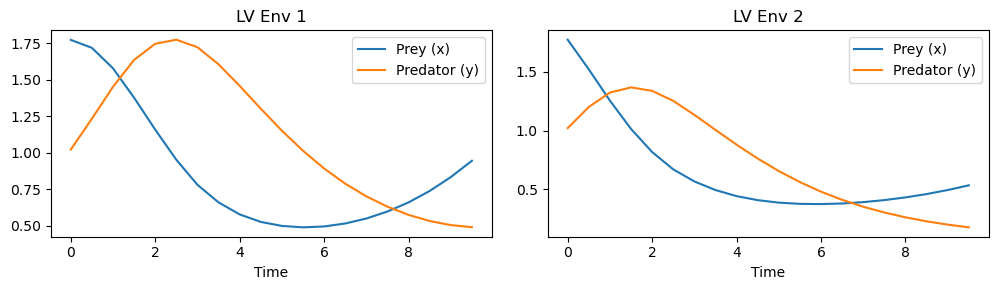

Shape of gs_trajs[0]: (2, 10, 32, 32)
Shape of lv_trajs[0]: (2, 20)
Shape of gs_trajs[1]: (2, 10, 32, 32)
Shape of lv_trajs[1]: (2, 20)
Shape of gs_trajs[0]: (2, 10, 32, 32)
Shape of lv_trajs[0]: (2, 20)


In [15]:
# Plot LV (first 2 envs)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for i in range(min(2, len(lv_trajs))):
    axes[i].plot(lv_times, lv_trajs[i][0], label='Prey (x)')
    axes[i].plot(lv_times, lv_trajs[i][1], label='Predator (y)')
    axes[i].set_title(f'LV Env {i+1}')
    axes[i].set_xlabel('Time')
    axes[i].legend()
plt.tight_layout()
plt.show()

print("Shape of gs_trajs[0]:", gs_trajs[0].shape)
print("Shape of lv_trajs[0]:", lv_trajs[0].shape)
print("Shape of gs_trajs[1]:", gs_trajs[1].shape)
print("Shape of lv_trajs[1]:", lv_trajs[1].shape)

print("Shape of gs_trajs[0]:", gs_trajs[0].shape)
print("Shape of lv_trajs[0]:", lv_trajs[0].shape)

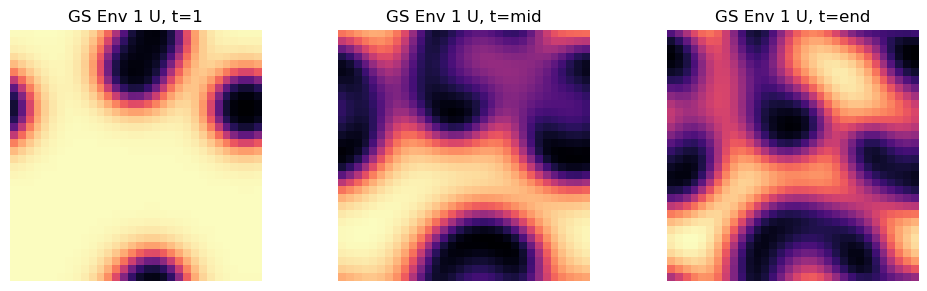

In [16]:
# Visualize GS spatial fields: use axes[i] and 2D slices of gs_trajs[env]
# gs_trajs[env] has shape (2, n, gs_size, gs_size) -> [channel U/V, time, x, y]
env = 0  # which environment to plot
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
# Show U at t=1, t=mid, t=end (use axes[0], axes[1], axes[2])
axes[0].imshow(gs_trajs[env][0, 1], cmap='magma')
axes[0].set_title(f"GS Env {env+1} U, t=1")
axes[0].axis('off')
axes[1].imshow(gs_trajs[env][0, gs_n // 2], cmap='magma')
axes[1].set_title(f"GS Env {env+1} U, t=mid")
axes[1].axis('off')
axes[2].imshow(gs_trajs[env][0, -1], cmap='magma')
axes[2].set_title(f"GS Env {env+1} U, t=end")
axes[2].axis('off')
plt.tight_layout()
plt.show()

## 2. Noise Introduction
    - To emulate real-world condtions, a small amount of Gaussian noise is introduced to the trianing matrices

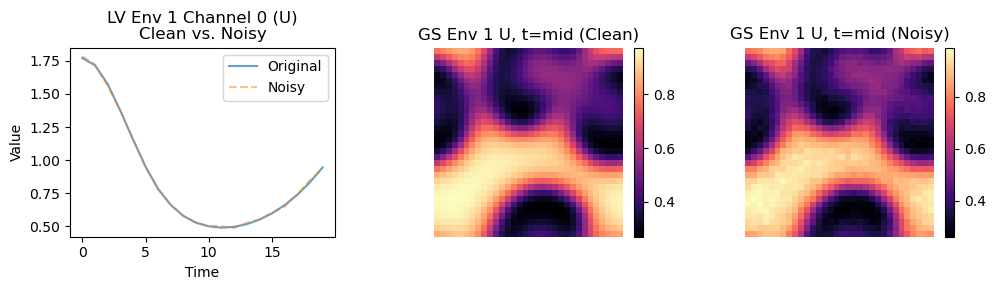

In [17]:
# Add Gaussian noise (sigma=0.01) to the one training trajectory per env
sigma = 0.01
np.random.seed(10)

lv_trajs_noisy = [traj + np.random.normal(0, sigma, traj.shape) for traj in lv_trajs]
gs_trajs_noisy = [traj + np.random.normal(0, sigma, traj.shape) for traj in gs_trajs]

# Use lv_trajs_noisy / gs_trajs_noisy for SINDy fitting; keep lv_trajs / gs_trajs for evaluation

env = 0  # choose first environment
channel = 0  # U in LV/GS (can try 1 for V)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# LV: plot time series of U, noisy vs original
axes[0].plot(lv_trajs[env][channel], label="Original", alpha=0.7)
axes[0].plot(lv_trajs_noisy[env][channel], '--', label="Noisy", alpha=0.5)
axes[0].set_title(f"LV Env {env+1} Channel {channel} (U)\nClean vs. Noisy")
axes[0].legend()
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")

# GS: plot single-spatial field at t=mid (original vs noisy)
mid = gs_trajs[env].shape[1] // 2

im1 = axes[1].imshow(gs_trajs[env][0, mid], cmap="magma")
axes[1].set_title(f"GS Env {env+1} U, t=mid (Clean)")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(gs_trajs_noisy[env][0, mid], cmap="magma")
axes[2].set_title(f"GS Env {env+1} U, t=mid (Noisy)")
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 3. Model Fitting (One-Per-Env Strategy)
    - For each environment, feed the noisy training trajectory into two separate PySINDy models (fit independently per environment; do not mix data, as this aims to replicate the "One-Per-Env" baseline):

In [18]:
import pysindy as ps
import numpy as np

models_lv = []

for env in range(len(lv_params)):
    
    X = lv_trajs_noisy[env].T
    t_norm = lv_times / np.max(lv_times)
    dt = t_norm[1] - t_norm[0]

    library = ps.PolynomialLibrary(degree=2)

    optimizer = ps.STLSQ(threshold=0.001)

    diff_method = ps.SmoothedFiniteDifference()

    # for standard SINDy
    sindy_standard = ps.SINDy(
        feature_library=library,
        optimizer=optimizer,
        differentiation_method=diff_method
    )
    sindy_standard.fit(X, t=dt)

    # for Ensemble SINDy (E-SINDy)
    ensemble_optimizer = ps.EnsembleOptimizer(
        optimizer,
        n_models=100,
        bagging=True
    )

    sindy_ensemble = ps.SINDy(
        feature_library=library,
        optimizer=ensemble_optimizer,
        differentiation_method=diff_method
    )
    sindy_ensemble.fit(X, t=dt)

    models_lv.append({
        "SINDy": sindy_standard,
        "Ensemble_SINDy": sindy_ensemble
    })

print(f"Successfully fitted {len(models_lv)} LV environments.")

Successfully fitted 2 LV environments.


In [19]:
import pysindy as ps
import numpy as np

models_gs = []

for env in range(len(gs_params)):

    # shape likely: (n_traj, n_time, n_state)
    X_env = gs_trajs_noisy[env].T

    t_norm = gs_times / np.max(gs_times)
    dt = t_norm[1] - t_norm[0]

    # polynomial feature library (similar to EDMD polynomial kernel)
    library = ps.PolynomialLibrary(degree=2)

    optimizer = ps.STLSQ(threshold=0.001) #lowered threshold

    diff_method = ps.SmoothedFiniteDifference()

    # Standard SINDy model
    sindy_model = ps.SINDy(
        feature_library=library,
        optimizer=optimizer,
        differentiation_method=diff_method
    )

    sindy_model.fit(X_env, t=dt)

    # Ensemble SINDy (E-SINDy) model
    ensemble_optimizer = ps.EnsembleOptimizer(
        optimizer,
        n_models=100,
        bagging=True
    )

    esindy_model = ps.SINDy(
        feature_library=library,
        optimizer=ensemble_optimizer,
        differentiation_method=diff_method
    )

    esindy_model.fit(X_env, t=dt)

    models_gs.append({
        "SINDy": sindy_model,
        "E-SINDy": esindy_model
    })

print(f"Successfully fitted {len(models_gs)} GS environments.")

Successfully fitted 2 GS environments.


In [20]:
# Display results for LV last environment
print("\nLotka–Volterra:")

print("\nStandard SINDy model:")
models_lv[-1]["SINDy"].print()

print("\nEnsemble SINDy model:")
models_lv[-1]["Ensemble_SINDy"].print()

print()

# Display results for Gray-Scott last environment
print("\nGray-Scott:")

print("\nStandard SINDy model:")
models_gs[-1]["SINDy"].print()

print("\nEnsemble SINDy model:")
models_lv[-1]["Ensemble_SINDy"].print()


Lotka–Volterra:

Standard SINDy model:
(x0)' = -0.277 1 +  3.131 x0 +  0.299 x1 + -2.449 x0^2 + -1.338 x0 x1 + -1.522 x1^2
(x1)' =  2.637 1 + -6.335 x0 + -7.109 x1 +  3.350 x0^2 +  4.121 x0 x1 +  2.373 x1^2

Ensemble SINDy model:
(x0)' =  0.302 1 +  1.929 x0 + -0.329 x1 + -1.955 x0^2 + -1.211 x0 x1 + -1.085 x1^2
(x1)' =  2.472 1 + -5.991 x0 + -6.990 x1 +  3.228 x0^2 +  3.966 x0 x1 +  2.298 x1^2


Gray-Scott:

Standard SINDy model:
(x0)' = -0.320 1 +  0.687 x0 +  1.018 x1 + -0.371 x0^2 + -1.165 x0 x1 + -0.455 x1^2
(x1)' =  0.201 1 + -0.433 x0 + -0.805 x1 +  0.236 x0^2 +  0.930 x0 x1 +  0.476 x1^2

Ensemble SINDy model:
(x0)' =  0.302 1 +  1.929 x0 + -0.329 x1 + -1.955 x0^2 + -1.211 x0 x1 + -1.085 x1^2
(x1)' =  2.472 1 + -5.991 x0 + -6.990 x1 +  3.228 x0^2 +  3.966 x0 x1 +  2.298 x1^2


## 4. Visualization
    - 

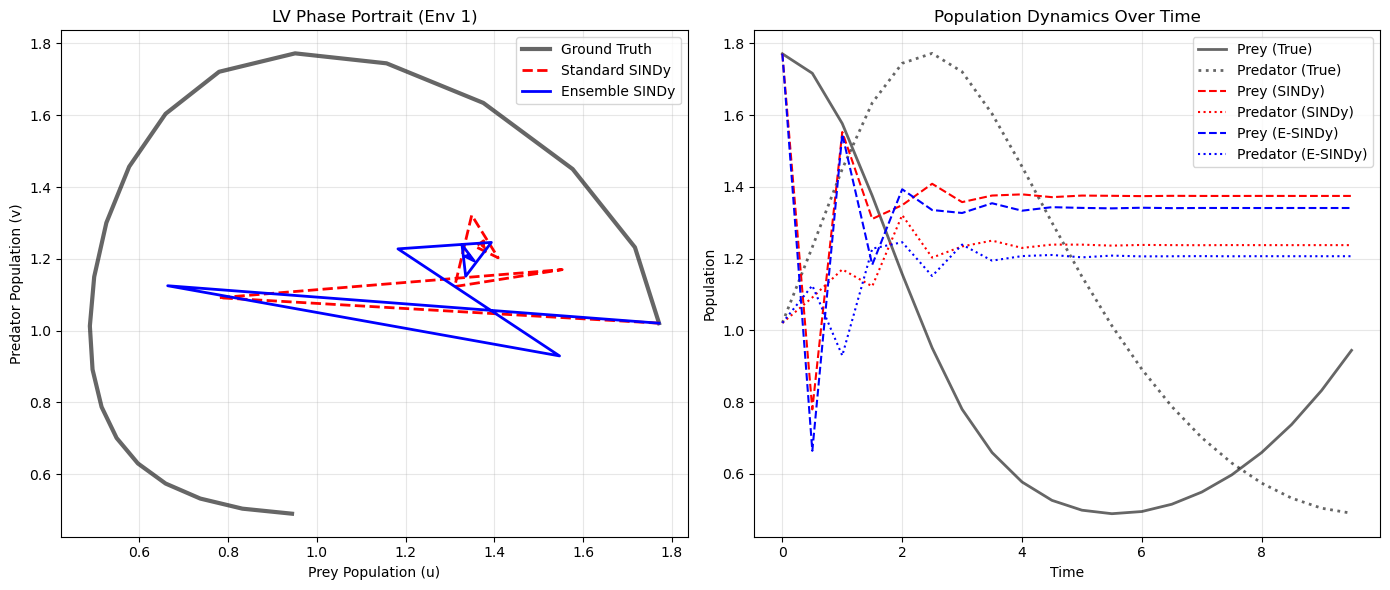

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Choose a representative environment
lv_env = 0

# Extract the SINDy models
sindy_lv = models_lv[lv_env]["SINDy"]
esindy_lv = models_lv[lv_env]["Ensemble_SINDy"]

# Extract ground truth
X_true = lv_trajs[lv_env]

# Time vector
t = lv_times

# Initial condition (first point of the trajectory)
x0 = X_true[:, 0]

# --- Simulate SINDy and Ensemble SINDy ---
X_sindy_pred = sindy_lv.simulate(x0, t)
X_esindy_pred = esindy_lv.simulate(x0, t)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Phase Portrait (Prey vs Predator)
axes[0].plot(X_true[0], X_true[1], "k-", lw=3, alpha=0.6, label="Ground Truth")
axes[0].plot(X_sindy_pred[:, 0], X_sindy_pred[:, 1], "r--", lw=2, label="Standard SINDy")
axes[0].plot(X_esindy_pred[:, 0], X_esindy_pred[:, 1], "b-", lw=2, label="Ensemble SINDy")

axes[0].set_xlabel("Prey Population (u)")
axes[0].set_ylabel("Predator Population (v)")
axes[0].set_title(f"LV Phase Portrait (Env {lv_env+1})")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Time Series Evolution
axes[1].plot(t, X_true[0], "k-", lw=2, alpha=0.6, label="Prey (True)")
axes[1].plot(t, X_true[1], "k:", lw=2, alpha=0.6, label="Predator (True)")

axes[1].plot(t, X_sindy_pred[:, 0], "r--", lw=1.5, label="Prey (SINDy)")
axes[1].plot(t, X_sindy_pred[:, 1], "r:", lw=1.5, label="Predator (SINDy)")

axes[1].plot(t, X_esindy_pred[:, 0], "b--", lw=1.5, label="Prey (E-SINDy)")
axes[1].plot(t, X_esindy_pred[:, 1], "b:", lw=1.5, label="Predator (E-SINDy)")

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Population")
axes[1].set_title("Population Dynamics Over Time")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

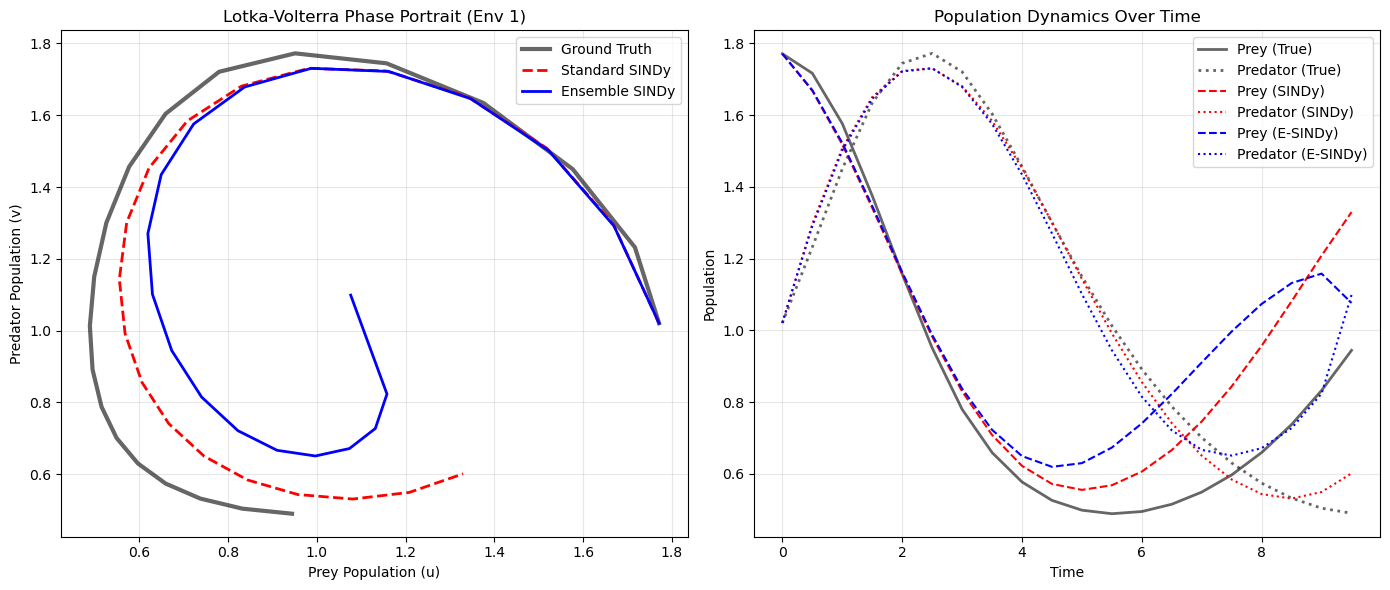

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps

# Choose environment
lv_env = 0
X_true = lv_trajs[lv_env]       # shape: (n_state, n_time)
X_noisy = lv_trajs_noisy[lv_env]  # noisy version
t = lv_times                     # time vector
dt = t[1] - t[0]
x0 = X_true[:, 0]                # initial condition

# Build library and SINDy models
library = ps.PolynomialLibrary(degree=2, include_interaction=True)  # add x*y terms
diff_method = ps.SmoothedFiniteDifference()
optimizer = ps.STLSQ(threshold=1e-4)  # lower threshold to keep key interactions

# --- Standard SINDy ---
sindy_lv = ps.SINDy(
    feature_library=library,
    optimizer=optimizer,
    differentiation_method=diff_method
)
sindy_lv.fit(X_noisy.T, t=dt)

# --- Ensemble SINDy ---
ensemble_optimizer = ps.EnsembleOptimizer(
    optimizer,
    n_models=100,
    bagging=True
)
esindy_lv = ps.SINDy(
    feature_library=library,
    optimizer=ensemble_optimizer,
    differentiation_method=diff_method
)
esindy_lv.fit(X_noisy.T, t=dt)


# Simulate trajectories

# Standard SINDy
X_sindy_pred = sindy_lv.simulate(x0, t)

# Ensemble SINDy: only stable models
stable_coefs = []
X_ensemble_sim_all = []

coef_threshold = 10  # adjust if needed
for coef in esindy_lv.optimizer.coef_list:
    if np.max(np.abs(coef)) > coef_threshold:
        continue
    esindy_lv.optimizer.coef_ = coef
    try:
        sim = esindy_lv.simulate(x0, t, integrator='RK45', integrator_kws={'max_step': dt/10})
        X_ensemble_sim_all.append(sim)
        stable_coefs.append(coef)
    except:
        continue

X_ensemble_sim_all = np.array(X_ensemble_sim_all)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Phase Portrait
axes[0].plot(X_true[0], X_true[1], "k-", lw=3, alpha=0.6, label="Ground Truth")
axes[0].plot(X_sindy_pred[:, 0], X_sindy_pred[:, 1], "r--", lw=2, label="Standard SINDy")
axes[0].plot(X_esindy_pred[:, 0], X_esindy_pred[:, 1], "b-", lw=2, label="Ensemble SINDy")
axes[0].set_xlabel("Prey Population (u)")
axes[0].set_ylabel("Predator Population (v)")
axes[0].set_title(f"Lotka-Volterra Phase Portrait (Env {lv_env+1})")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Time Series Evolution
axes[1].plot(t, X_true[0], "k-", lw=2, alpha=0.6, label="Prey (True)")
axes[1].plot(t, X_true[1], "k:", lw=2, alpha=0.6, label="Predator (True)")
axes[1].plot(t, X_sindy_pred[:, 0], "r--", lw=1.5, label="Prey (SINDy)")
axes[1].plot(t, X_sindy_pred[:, 1], "r:", lw=1.5, label="Predator (SINDy)")
axes[1].plot(t, X_esindy_pred[:, 0], "b--", lw=1.5, label="Prey (E-SINDy)")
axes[1].plot(t, X_esindy_pred[:, 1], "b:", lw=1.5, label="Predator (E-SINDy)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Population")
axes[1].set_title("Population Dynamics Over Time")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sindy_gs_summary(model, X_env_flat, X_env_original, gs_times, gs_size):

    x0 = X_env_flat[0]

    fig, axes = plt.subplots(3,3, figsize=(14,10))

    # ----------------------------
    # Row 1: coefficient amplitudes
    # ----------------------------

    Xi = model.coefficients()
    coef_amp = np.abs(Xi).sum(axis=1)

    axes[0,0].scatter(np.arange(len(coef_amp)), coef_amp)
    axes[0,0].set_title("Coefficient Magnitudes")

    # ----------------------------
    # Row 1: eigenvalues
    # ----------------------------

    try:
        J = model.jacobian(np.zeros_like(x0))
        eig_c = np.linalg.eigvals(J)

        dt = gs_times[1] - gs_times[0]
        eig_d = np.exp(eig_c * dt)

    except:
        eig_c = []
        eig_d = []

    theta = np.linspace(0,2*np.pi,200)

    axes[0,1].plot(np.cos(theta), np.sin(theta),'k--')

    if len(eig_d) > 0:
        axes[0,1].scatter(eig_d.real, eig_d.imag)

    axes[0,1].set_title("Discrete Eigenvalues")
    axes[0,1].set_aspect("equal")

    if len(eig_c) > 0:
        axes[0,2].scatter(eig_c.real, eig_c.imag)

    axes[0,2].axvline(0, linestyle="--")
    axes[0,2].set_title("Continuous Eigenvalues")

    # ----------------------------
    # Row 2: Gray-Scott spatial fields
    # ----------------------------

    U = X_env_original[0]
    V = X_env_original[1]

    sns.heatmap(U.mean(axis=0), ax=axes[1,0], cmap="magma", xticklabels=False, yticklabels=False)
    axes[1,0].set_title("Mean U Field")

    sns.heatmap(V.mean(axis=0), ax=axes[1,1], cmap="magma", xticklabels=False, yticklabels=False)
    axes[1,1].set_title("Mean V Field")

    sns.heatmap(U[-1], ax=axes[1,2], cmap="magma", xticklabels=False, yticklabels=False)
    axes[1,2].set_title("Final U Field")

    # ----------------------------
    # Row 3: dynamics
    # ----------------------------

    try:
        X_sim = model.simulate(x0, gs_times, integrator="odeint")
    except:
        X_sim = np.zeros_like(X_env_flat)

    axes[2,0].plot(gs_times, X_env_flat[:,0], label="Data")
    axes[2,0].plot(gs_times, X_sim[:,0], label="SINDy")
    axes[2,0].set_title("State 0 Dynamics")
    axes[2,0].legend()

    axes[2,1].plot(gs_times, X_env_flat[:,1], label="Data")
    axes[2,1].plot(gs_times, X_sim[:,1], label="SINDy")
    axes[2,1].set_title("State 1 Dynamics")
    axes[2,1].legend()

    axes[2,2].axis("off")

    plt.suptitle("Summary: Gray-Scott (Env 1)", fontsize=16)
    plt.tight_layout(rect=[0, 0, .9, 1])
    plt.show()

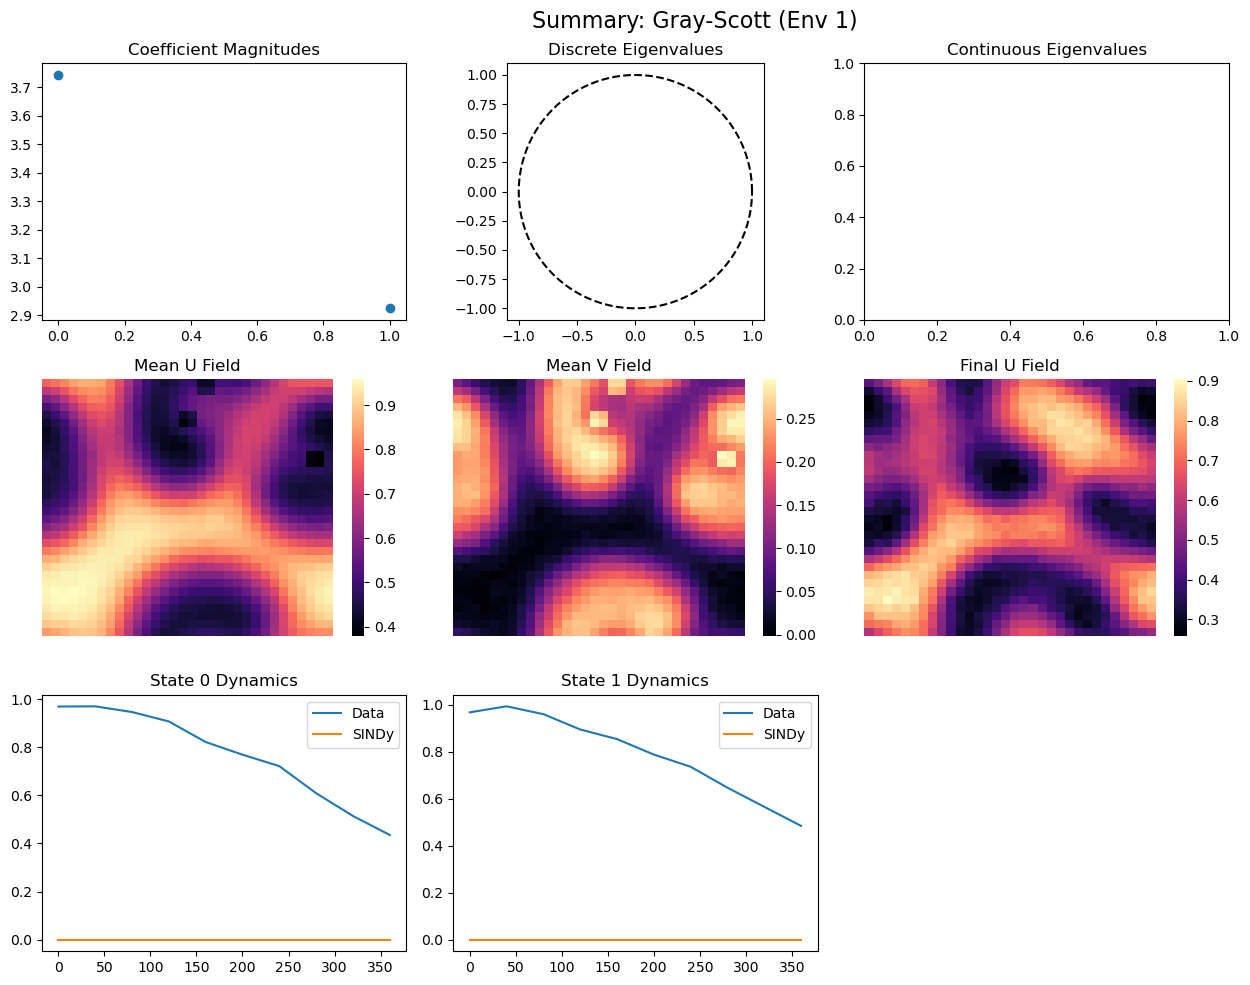

In [107]:
gs_env = 0

X_env_original = gs_trajs_noisy[gs_env]

n_vars, n_time, nx, ny = X_env_original.shape

X_env_flat = (
    X_env_original
    .reshape(n_vars, n_time, nx*ny)
    .transpose(1,0,2)
    .reshape(n_time, -1)
)

plot_sindy_gs_summary(
    model=models_gs[gs_env]["SINDy"],
    X_env_flat=X_env_flat,
    X_env_original=X_env_original,
    gs_times=gs_times,
    gs_size=gs_size
)

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def plot_gs_summary_sindy(model, name, gs_env, gs_times, gs_dt_eval, gs_size,
                          X_env_flat, X_env_original):

    # ----- SINDy equivalents -----

    Xi = model.coefficients()
    amplitudes = np.abs(Xi).sum(axis=1)

    try:
        J = model.jacobian(np.zeros(X_env_flat.shape[1]))
        eigs_c = np.linalg.eigvals(J)
        eigs_d = np.exp(eigs_c * gs_dt_eval)
    except:
        eigs_c = np.array([])
        eigs_d = np.array([])

    # Spatial data
    U = X_env_original[0]
    V = X_env_original[1]

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))

    # ----------------------------
    # Mode amplitudes
    # ----------------------------
    sns.scatterplot(
        x=np.arange(len(amplitudes)),
        y=amplitudes,
        ax=axes[0, 0],
        s=70,
        color="darkorange",
        edgecolor="k"
    )

    axes[0, 0].set_title("Mode Amplitudes")
    axes[0, 0].set_ylabel("Amplitude")

    # ----------------------------
    # Discrete eigenvalues
    # ----------------------------
    theta = np.linspace(0, 2*np.pi, 100)

    axes[0, 1].plot(np.cos(theta), np.sin(theta), "k--", alpha=0.5)

    if eigs_d.size > 0:
        sns.scatterplot(
            x=eigs_d.real,
            y=eigs_d.imag,
            ax=axes[0, 1],
            s=100,
            color="mediumblue",
            edgecolor="k"
        )

    axes[0, 1].set_title("Discrete-time Eigenvalues")
    axes[0, 1].set_aspect("equal")

    # ----------------------------
    # Continuous eigenvalues
    # ----------------------------
    if eigs_c.size > 0:
        sns.scatterplot(
            x=eigs_c.real,
            y=eigs_c.imag,
            ax=axes[0, 2],
            s=100,
            color="crimson",
            edgecolor="k"
        )

    axes[0, 2].axvline(0, color="k", linestyle="--", alpha=0.5)
    axes[0, 2].set_title("Continuous-time Eigenvalues")

    # ----------------------------
    # Spatial modes (U component)
    # ----------------------------
    spatial_modes = [U.mean(axis=0), V.mean(axis=0), U[-1]]

    for i in range(3):
        sns.heatmap(
            spatial_modes[i],
            ax=axes[1, i],
            cmap="magma",
            xticklabels=False,
            yticklabels=False
        )
        axes[1, i].set_title(f"Mode {i+1} (U)")
        axes[1, i].axis("off")

    # ----------------------------
    # Mode dynamics
    # ----------------------------
    x0 = X_env_flat[0]

    try:
        X_sim = model.simulate(x0, gs_times, integrator="odeint")
    except:
        X_sim = np.zeros_like(X_env_flat)

    for i in range(3):
        idx = min(i, X_env_flat.shape[1] - 1)

        sns.lineplot(
            x=gs_times,
            y=X_sim[:, idx],
            ax=axes[2, i],
            color="blue"
        )

        axes[2, i].set_title(f"Mode {i+1} Dynamics")
        axes[2, i].set_xlabel("Time")

    plt.suptitle(f"{name} Summary: Gray-Scott (Env {gs_env+1})", fontsize=16)
    plt.tight_layout(rect=[0, 0, .9, 1])
    plt.show()

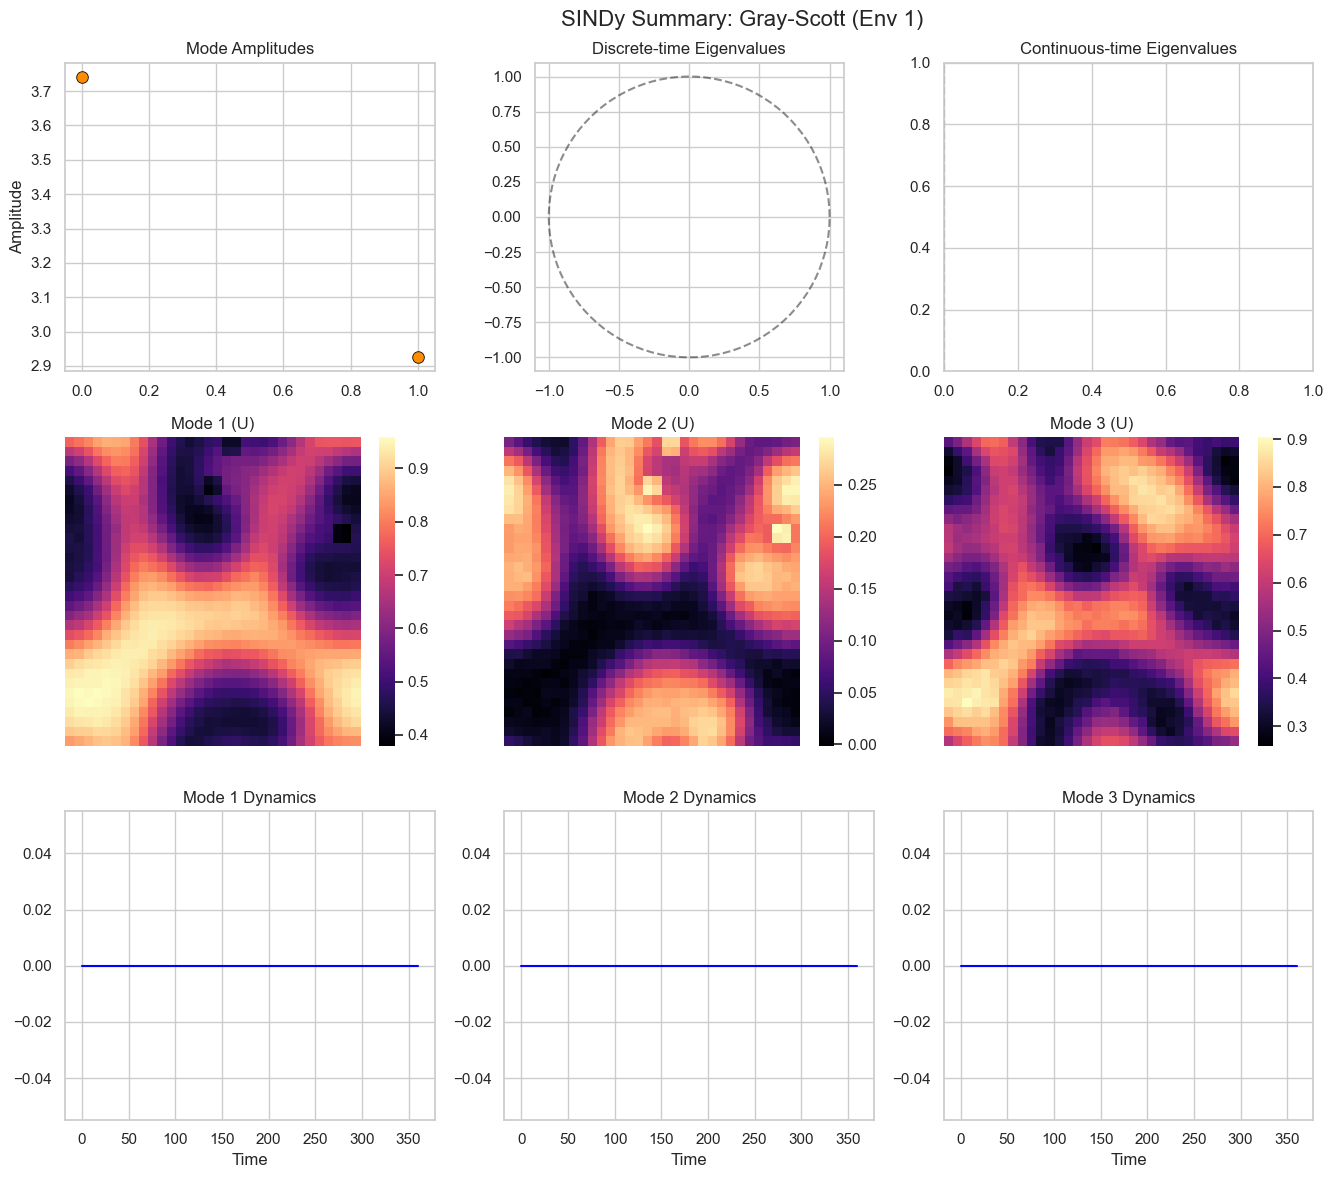

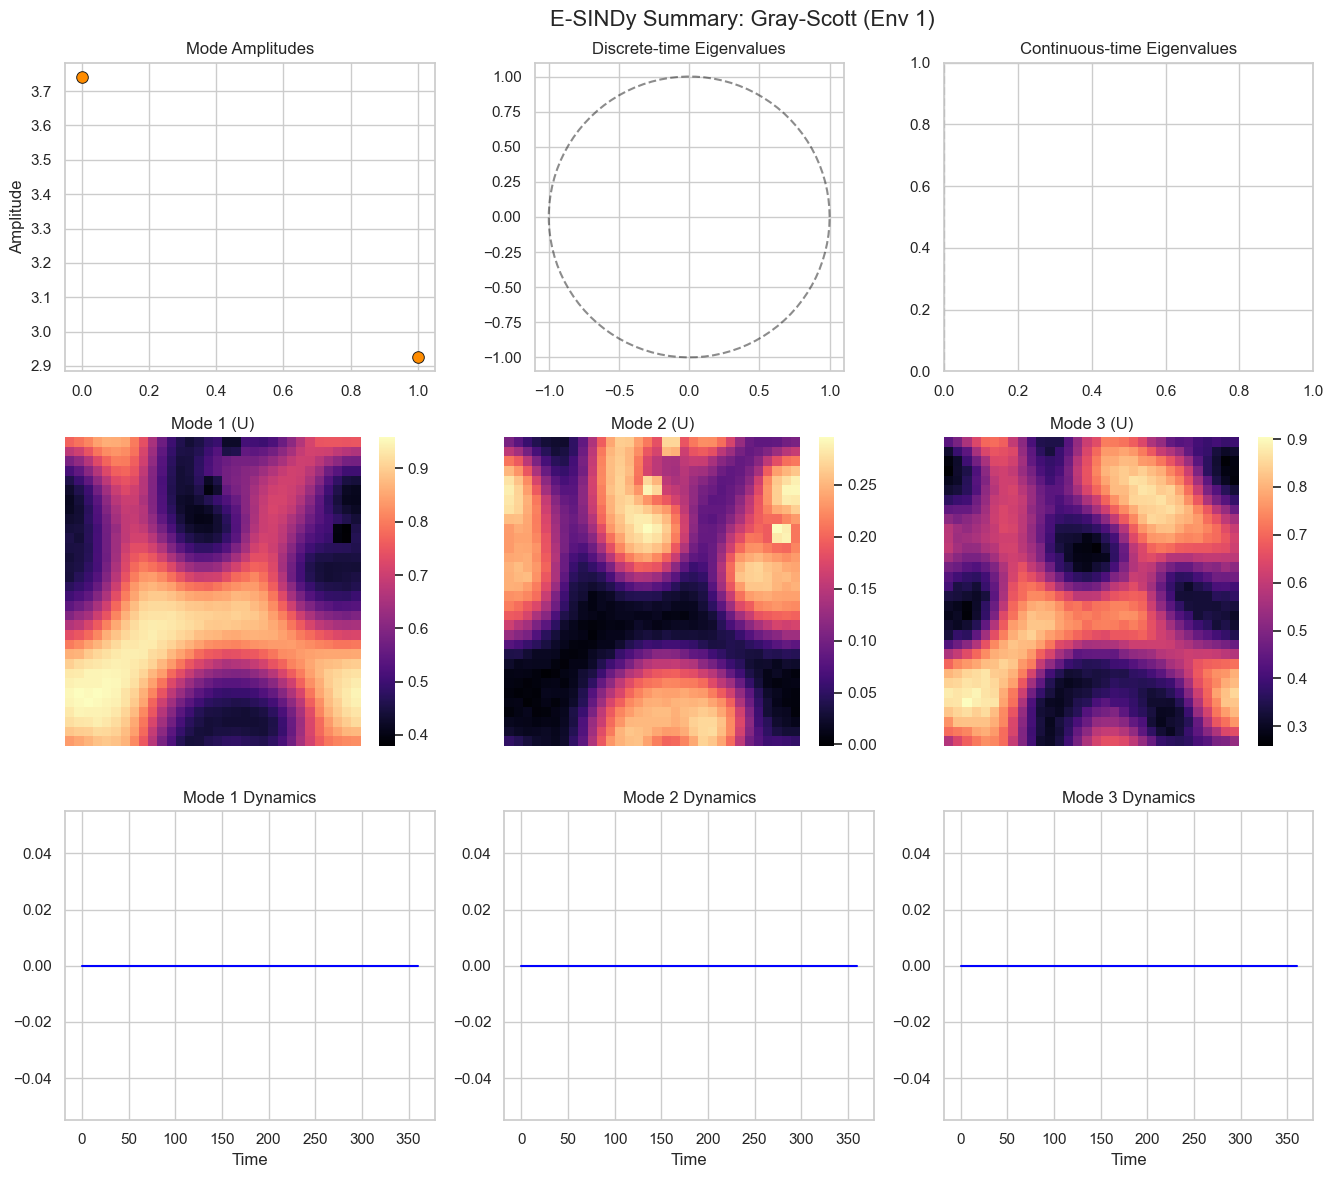

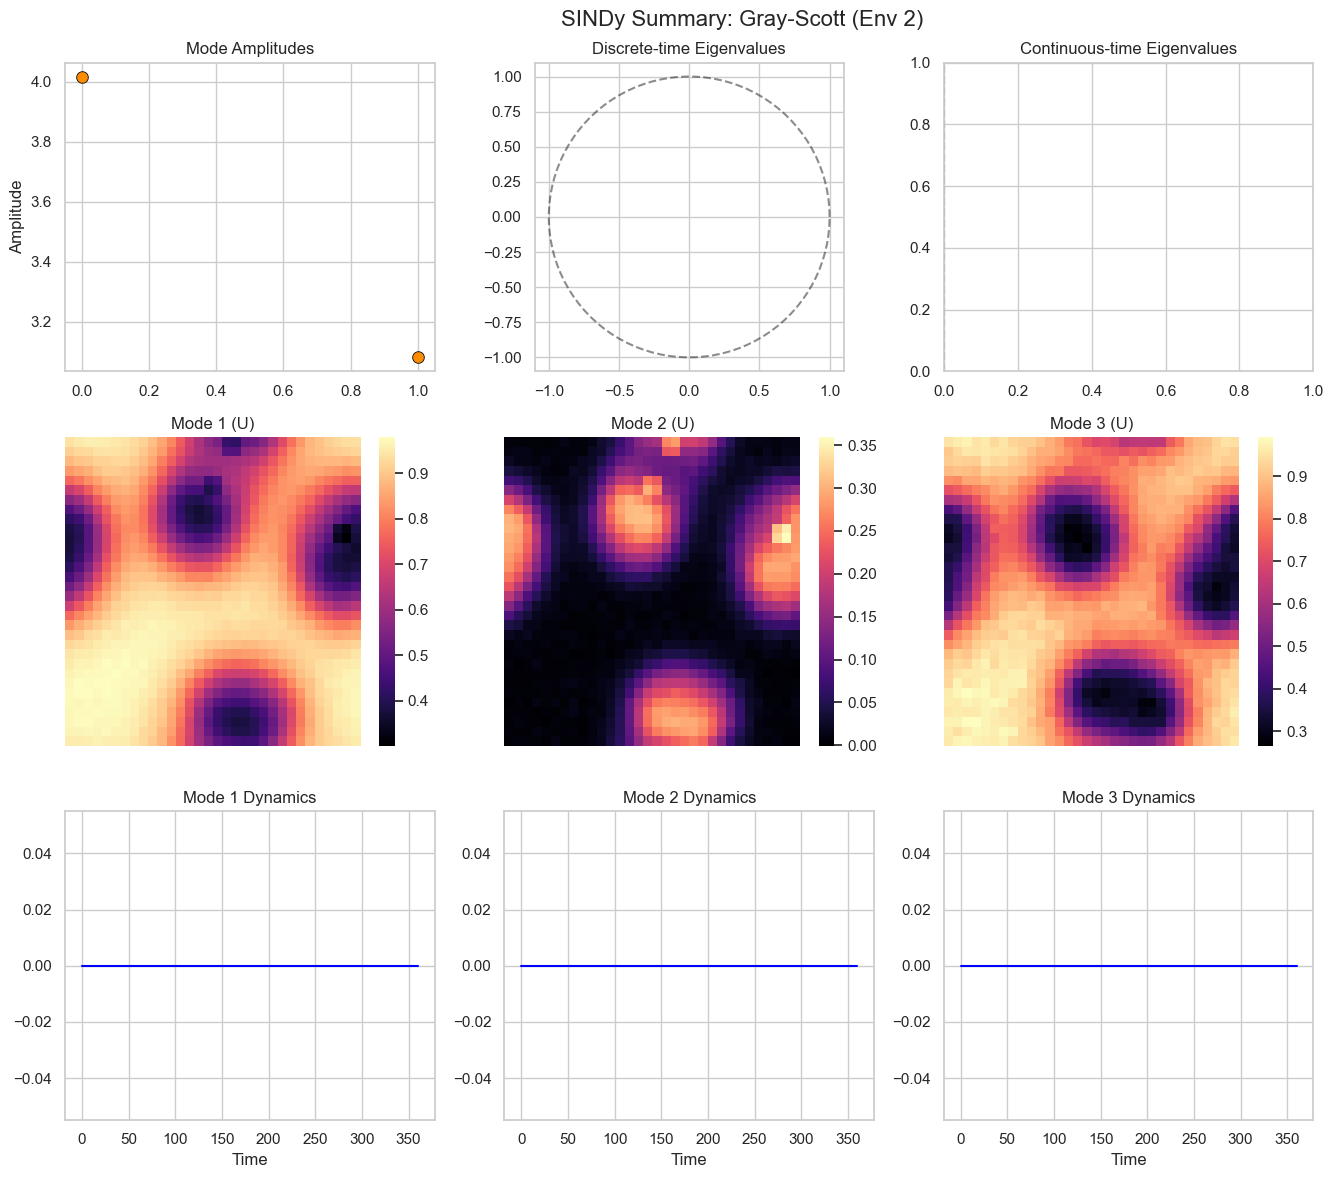

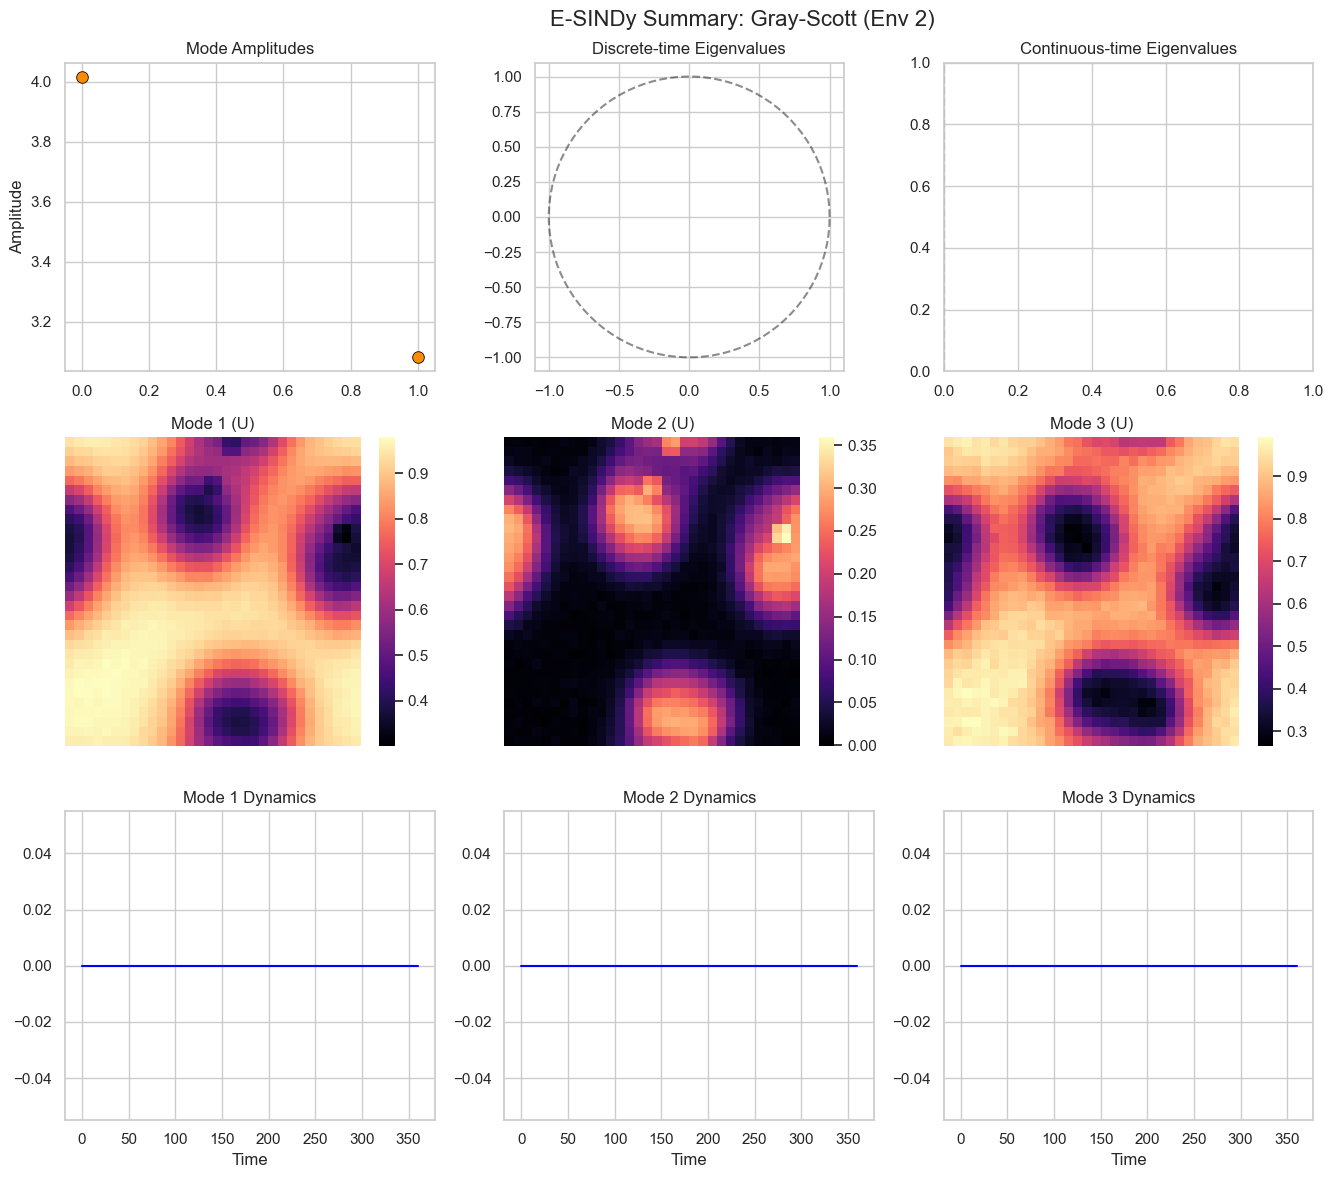

In [109]:
for gs_env in range(len(gs_params)):

    X_env_original = gs_trajs_noisy[gs_env]

    n_vars, n_time, nx, ny = X_env_original.shape

    X_env_flat = (
        X_env_original
        .reshape(n_vars, n_time, nx * ny)
        .transpose(1, 0, 2)
        .reshape(n_time, -1)
    )

    for name in ("SINDy", "E-SINDy"):

        plot_gs_summary_sindy(
            model=models_gs[gs_env][name],
            name=name,
            gs_env=gs_env,
            gs_times=gs_times,
            gs_dt_eval=gs_dt_eval,
            gs_size=gs_size,
            X_env_flat=X_env_flat,
            X_env_original=X_env_original
        )

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sindy_gs_summary_full(sindy_model, esindy_model, X_env, gs_times, gs_size, top_vars=3, title="SINDy Summary: Gray-Scott"):
    """
    3x3 summary for SINDy / E-SINDy on Gray-Scott PDE data.
    Layout similar to DMD summary:
    
    Row 1: Coefficient amplitudes, discrete eigenvalues, continuous eigenvalues
    Row 2: Spatial patterns (top_vars variables, U and V components)
    Row 3: Dynamics (SINDy vs E-SINDy mean ± std)
    """
    n_time, n_states = X_env.shape
    x0 = X_env[0, :]  # first timestep of environment

    # --------------------
    # 1️⃣ Compute coefficient amplitudes and eigenvalues
    # --------------------
    Xi = sindy_model.coefficients()
    var_std = X_env.std(axis=0)  # variance of each state

    # Jacobian at mean state
    x_star = np.mean(X_env, axis=0)
    def jacobian_at_point(model, x_star):
        Xi = model.coefficients()
        feature_names = model.get_feature_names()
        n = len(x_star)
        J = np.zeros((n, n))
        for i in range(n):
            for j, term in enumerate(feature_names):
                grad = np.zeros(n)
                if term == '1':
                    continue
                factors = term.split(' ')
                for f in factors:
                    if '^' in f:
                        var, power = f.split('^')
                        idx = int(var[1])
                        grad[idx] += float(power) * x_star[idx]**(float(power)-1)
                    else:
                        idx = int(f[1])
                        grad[idx] += 1.0
                J[i, :] += Xi[i, j] * grad
        return J

    J_std = jacobian_at_point(sindy_model, x_star)
    eig_std = np.linalg.eigvals(J_std)

    # Ensemble eigenvalues
    J_ens_list = []
    for coef in esindy_model.optimizer.coef_list:
        esindy_model.optimizer.coef_ = coef
        try:
            J = jacobian_at_point(esindy_model, x_star)
            J_ens_list.append(np.linalg.eigvals(J))
        except:
            continue
    eig_ensemble_all = np.array(J_ens_list)
    eig_ensemble_mean = eig_ensemble_all.mean(axis=0)
    eig_ensemble_std  = eig_ensemble_all.std(axis=0)

    # --------------------
    # 2️⃣ Top variable indices
    # --------------------
    top_idx = np.argsort(var_std)[-top_vars:]  # choose variables with largest variance

    fig, axes = plt.subplots(3, top_vars, figsize=(5*top_vars, 12))

    # --------------------
    # Row 1: amplitudes and eigenvalues
    # --------------------
    axes[0,0].bar(np.arange(len(coef_importance)), coef_importance, color='darkorange')
    axes[0,0].set_title("Coefficient Importance")

    axes[0,1].scatter(eig_std.real, eig_std.imag, color='r', label="SINDy")
    axes[0,1].errorbar(eig_ensemble_mean.real, eig_ensemble_mean.imag,
                       xerr=eig_ensemble_std.real, yerr=eig_ensemble_std.imag,
                       fmt='o', color='b', label="E-SINDy ± std")
    axes[0,1].axhline(0, color='k', linestyle='--')
    axes[0,1].axvline(0, color='k', linestyle='--')
    axes[0,1].set_aspect('equal')
    axes[0,1].set_title("Eigenvalues (Linearized)")
    axes[0,1].legend()

    axes[0,2].scatter(eig_std.real, eig_std.imag, color='r')
    axes[0,2].set_title("Eigenvalues (Continuous)")

    # --------------------
    # Row 2: Spatial patterns
    # --------------------
    for i, idx in enumerate(top_idx):
        # reshape back to 2D grid (assuming two species: U & V)
        mode_2d = X_env[:, idx].reshape(-1, 2, gs_size, gs_size)  # (time, species, nx, ny)
        mean_U = mode_2d[:,0].mean(axis=0)
        mean_V = mode_2d[:,1].mean(axis=0)

        axes[1,i].imshow(mean_U, cmap='magma')
        axes[1,i].set_title(f"Var {idx+1} Mean U")
        axes[1,i].axis('off')

    # --------------------
    # Row 3: Dynamics
    # --------------------
    X_sindy_sim = sindy_model.simulate(x0, gs_times)

    X_ensemble_sim_all = []
    for coef in esindy_model.optimizer.coef_list:
        esindy_model.optimizer.coef_ = coef
        try:
            sim = esindy_model.simulate(x0, gs_times)
            X_ensemble_sim_all.append(sim)
        except:
            continue
    X_ensemble_sim_all = np.array(X_ensemble_sim_all)
    X_ensemble_mean = X_ensemble_sim_all.mean(axis=0)
    X_ensemble_std  = X_ensemble_sim_all.std(axis=0)

    for i, idx in enumerate(top_idx):
        axes[2,i].plot(gs_times, X_env[:, idx], 'k-', lw=2, label='Data')
        axes[2,i].plot(gs_times, X_sindy_sim[:, idx], 'r--', lw=2, label='SINDy')
        axes[2,i].plot(gs_times, X_ensemble_mean[:, idx], 'b-', lw=2, label='E-SINDy')
        axes[2,i].fill_between(gs_times,
                               X_ensemble_mean[:, idx]-X_ensemble_std[:, idx],
                               X_ensemble_mean[:, idx]+X_ensemble_std[:, idx],
                               color='b', alpha=0.3)
        axes[2,i].set_title(f"Var {idx+1} Dynamics")
        axes[2,i].set_xlabel("Time")
        axes[2,i].legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

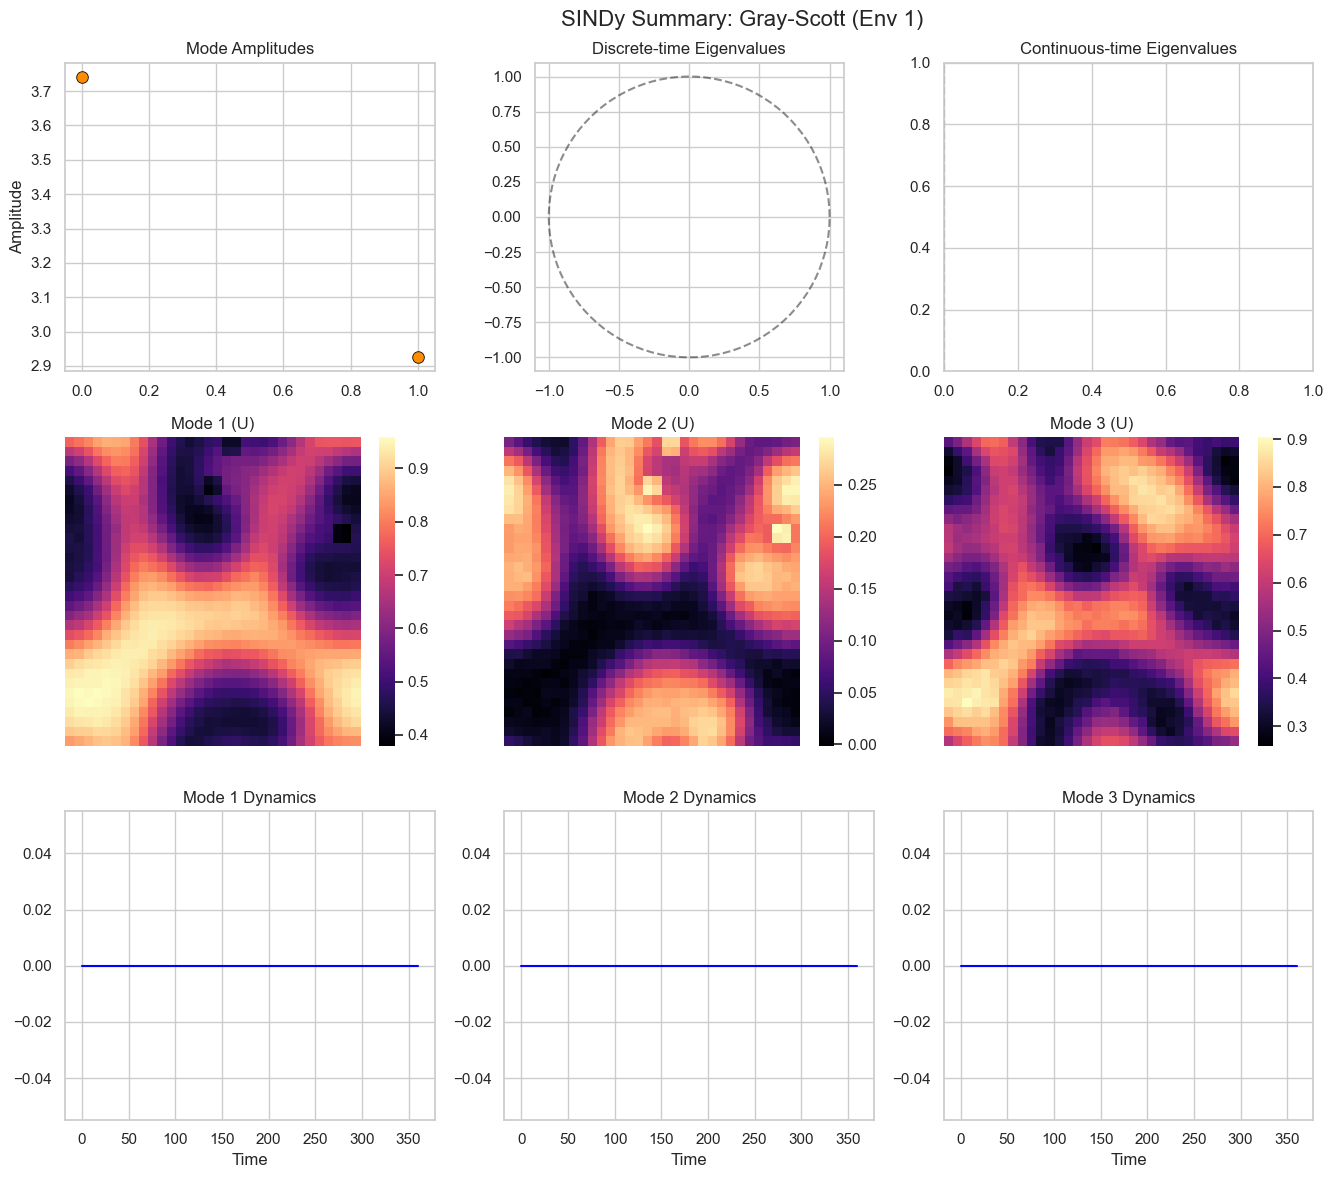

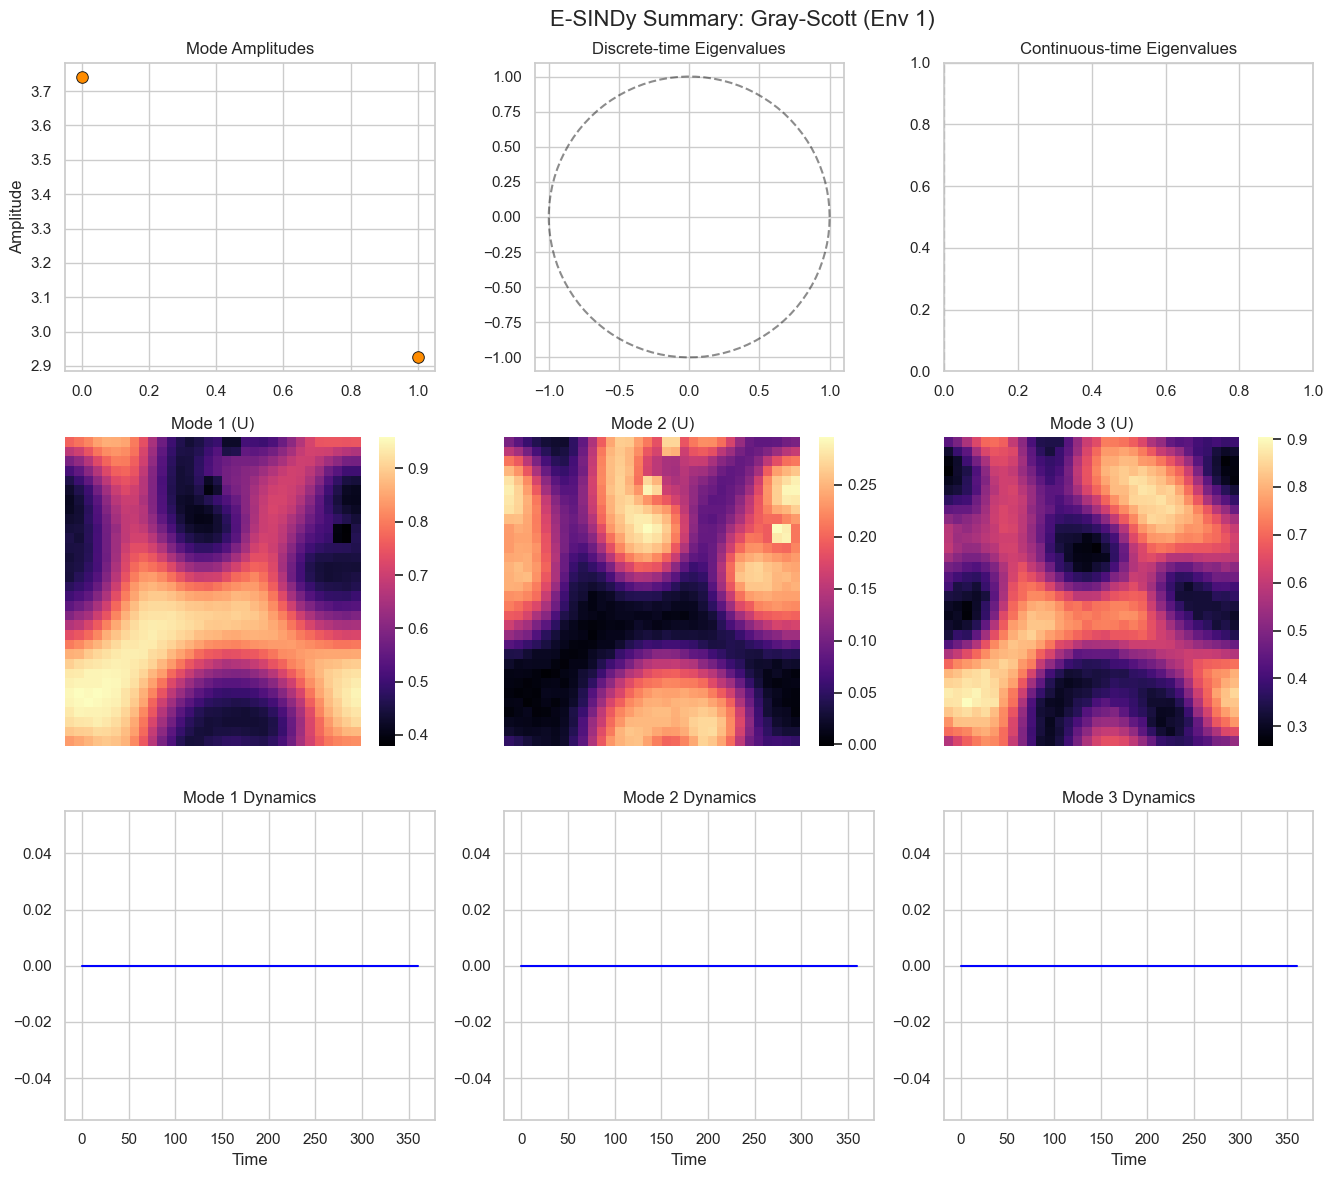

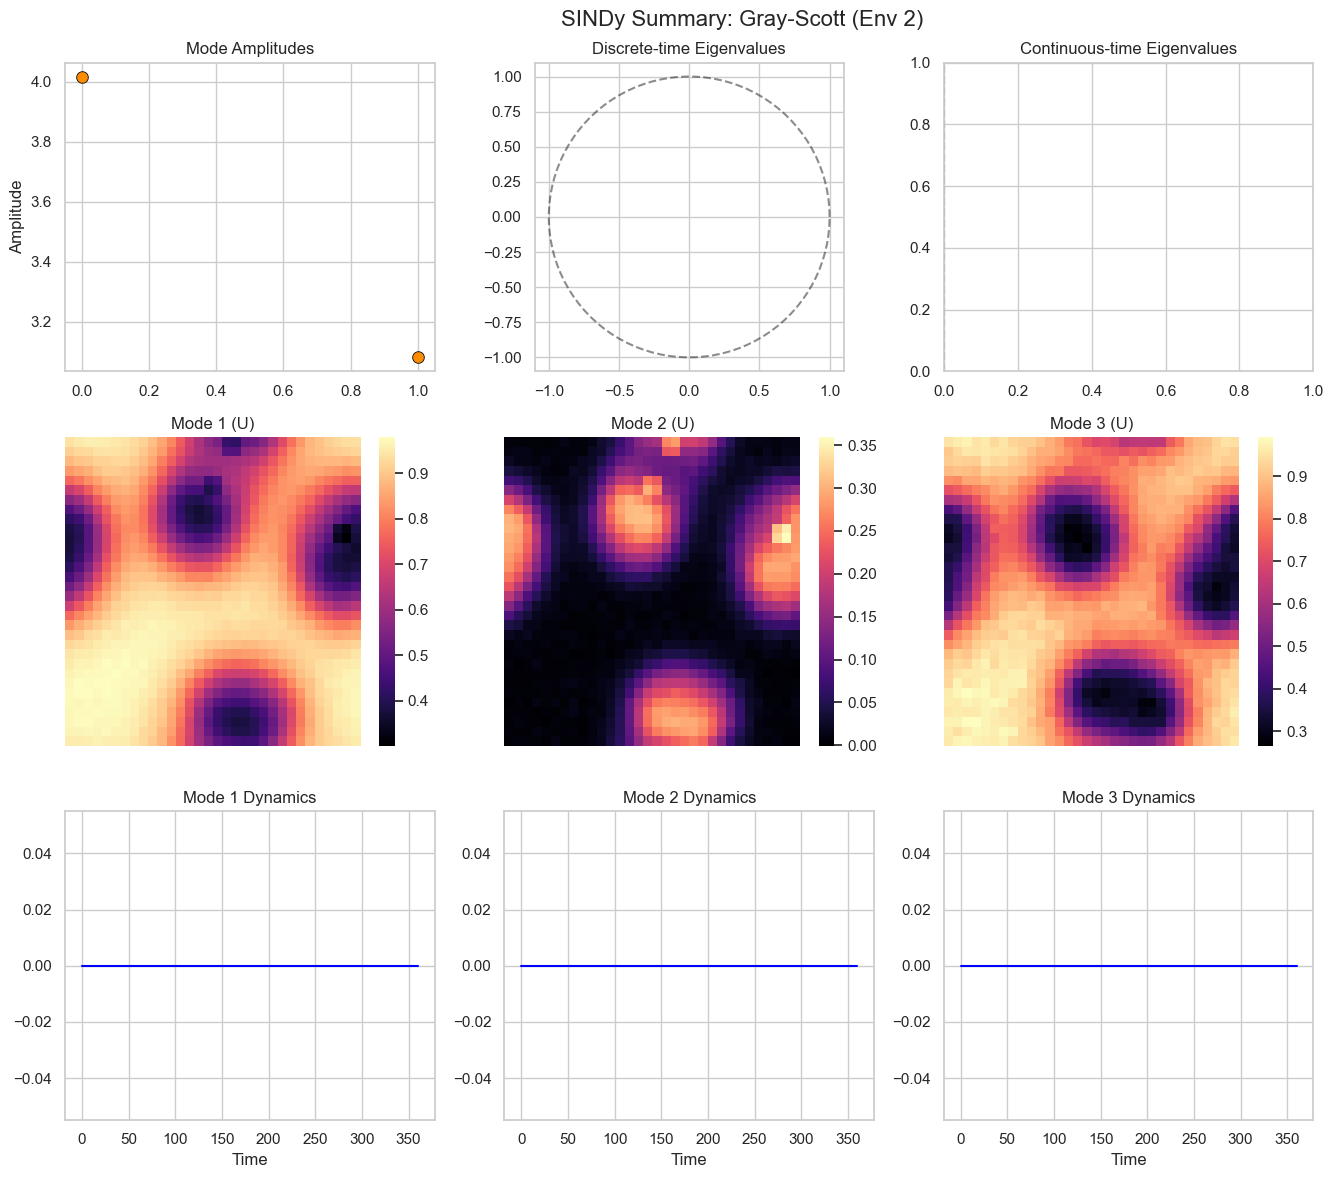

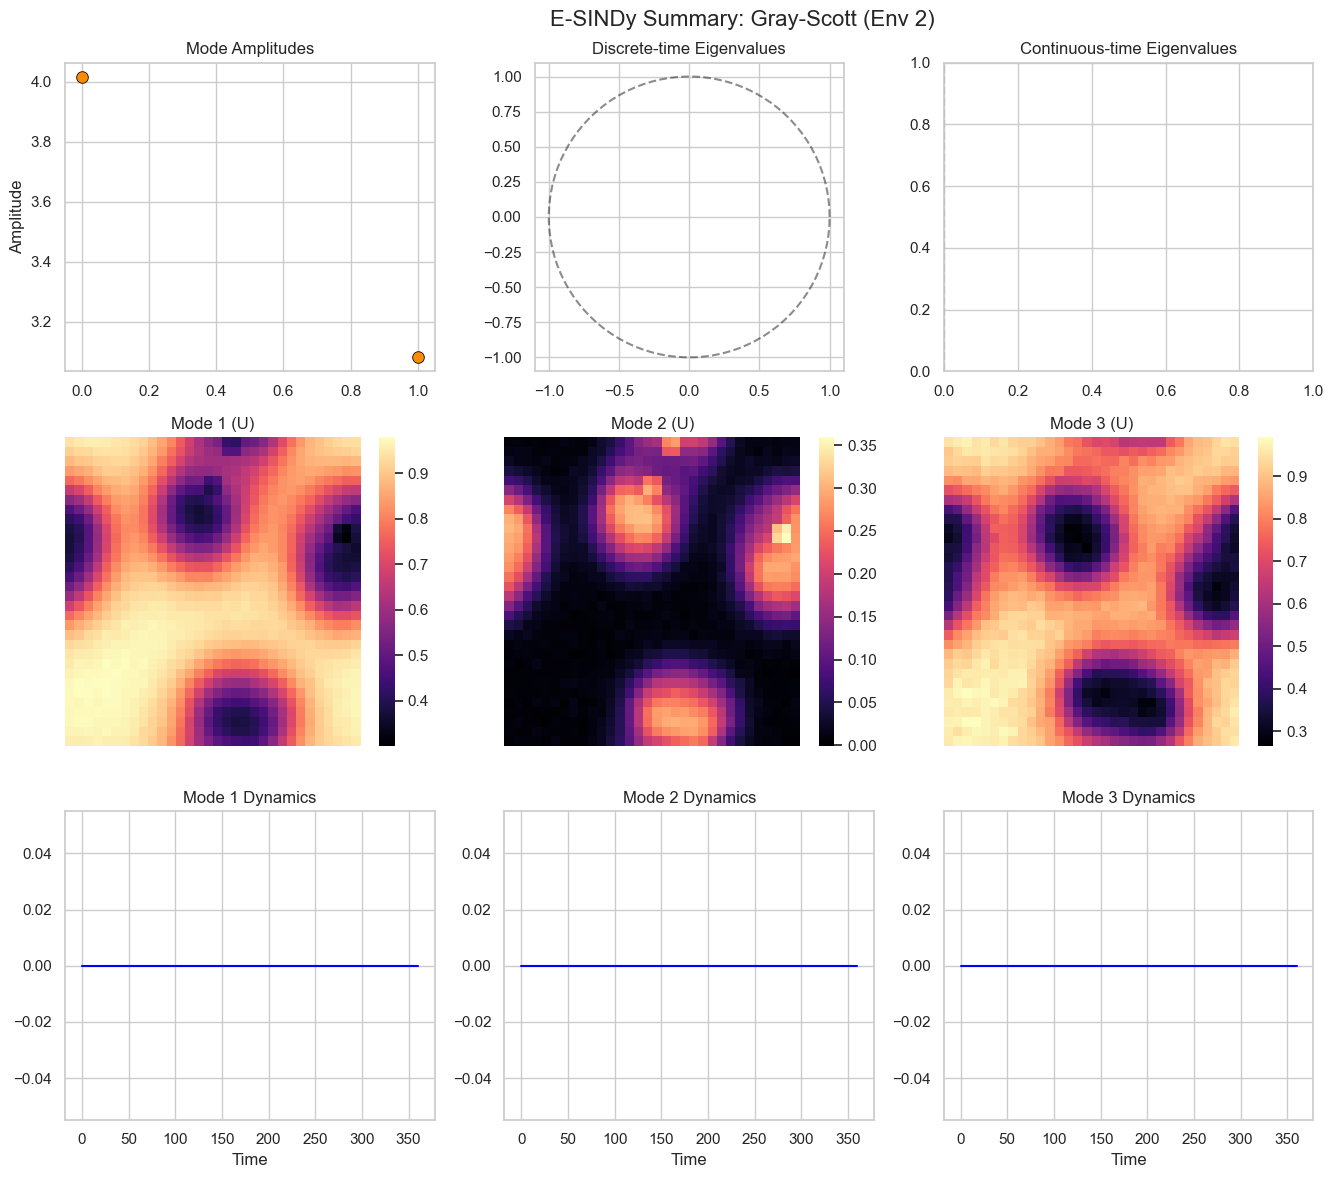

In [116]:
for gs_env in range(len(gs_params)):

    X_env_original = gs_trajs_noisy[gs_env]

    n_vars, n_time, nx, ny = X_env_original.shape

    # If original shape: (species, time, nx, ny)
    species, n_time, nx, ny = gs_trajs_noisy[0].shape
    X_env_flat = gs_trajs_noisy[0].transpose(1,0,2,3).reshape(n_time, -1)
    

    for name in ("SINDy", "E-SINDy"):

        plot_gs_summary_sindy(
            model=models_gs[gs_env][name],
            name=name,
            gs_env=gs_env,
            gs_times=gs_times,
            gs_dt_eval=gs_dt_eval,
            gs_size=gs_size,
            X_env_flat=X_env_flat,
            X_env_original=X_env_original
        )

# 5. Evaluation

In [24]:
import numpy as np
from sklearn.metrics import mean_squared_error

mse_lv_test = {"SINDy": [], "E-SINDy": []}

for env in range(len(models_lv)):
    
    for i in range(len(lv_test_trajs[env])):
        
        X_true = lv_test_trajs[env][i].T
        x0 = X_true[0]

        X_pred_sindy = models_lv[env]["SINDy"].simulate(x0, lv_times)
        mse_lv_test["SINDy"].append(mean_squared_error(X_true, X_pred_sindy))

        X_pred_esindy = models_lv[env]["E-SINDy"].simulate(x0, lv_times)
        mse_lv_test["E-SINDy"].append(mean_squared_error(X_true, X_pred_esindy))

mse_lv_avg = {k: np.mean(v) for k,v in mse_lv_test.items()}

rmse_sindy_lv = np.sqrt(mse_lv_avg["SINDy"])
rmse_esindy_lv = np.sqrt(mse_lv_avg["E-SINDy"])


mse_lv_test = {"SINDy": [], "E-SINDy": []}

for env in range(len(models_lv)):
    
    for i in range(len(lv_test_trajs[env])):
        
        X_true = lv_test_trajs[env][i].T
        x0 = X_true[0]

        X_pred_sindy = models_lv[env]["SINDy"].simulate(x0, lv_times)
        mse_lv_test["SINDy"].append(mean_squared_error(X_true, X_pred_sindy))

        X_pred_esindy = models_lv[env]["E-SINDy"].simulate(x0, lv_times)
        mse_lv_test["E-SINDy"].append(mean_squared_error(X_true, X_pred_esindy))

mse_lv_avg = {k: np.mean(v) for k,v in mse_lv_test.items()}

rmse_sindy_lv = np.sqrt(mse_lv_avg["SINDy"])
rmse_esindy_lv = np.sqrt(mse_lv_avg["E-SINDy"])


baselines = {
    "LV": {"mean": 1.16e-3, "std": 0.99e-3},
    "GS": {"mean": 2.08e-3, "std": 2.88e-3}
}


import matplotlib.pyplot as plt

datasets = ["LV", "GS"]

sindy_means = [rmse_sindy_lv, rmse_sindy_gs]
esindy_means = [rmse_esindy_lv, rmse_esindy_gs]
baseline_means = [baselines["LV"]["mean"], baselines["GS"]["mean"]]
baseline_std = [baselines["LV"]["std"], baselines["GS"]["std"]]

x = range(len(datasets))

plt.figure(figsize=(8,5))

plt.plot(x, sindy_means, marker='o', label="SINDy")
plt.plot(x, esindy_means, marker='s', label="E-SINDy")
plt.errorbar(x, baseline_means, yerr=baseline_std, marker='^',
             label="LEADS Baseline", capsize=5)

plt.xticks(x, datasets)
plt.ylabel("RMSE")
plt.yscale("log")
plt.title("Model Comparison: LV vs GS")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()

plt.show()

NameError: name 'lv_test_trajs' is not defined

In [49]:
import numpy as np
from sklearn.metrics import mean_squared_error

# ---- LV dataset ----
n_envs_lv = len(lv_params)
mse_lv = {"SINDy": [], "Ensemble_SINDy": []}

for env in range(n_envs_lv):
    X_true = lv_trajs[env].T  # (time, states)
    x0 = X_true[0]

    for model_name in ["SINDy", "Ensemble_SINDy"]:
        try:
            X_pred = models_lv[env][model_name].simulate(x0, lv_times)
            if np.any(np.isnan(X_pred)) or np.any(np.isinf(X_pred)):
                print(f"LV env {env}, model {model_name}: Simulation produced NaN/Inf, skipping.")
                continue
            mse = mean_squared_error(X_true, X_pred)
            mse_lv[model_name].append(mse)
        except Exception as e:
            print(f"LV env {env}, model {model_name}: Simulation failed with {e}")

# ---- GS dataset ----
n_envs_gs = len(gs_params)
mse_gs = {"SINDy": [], "Ensemble_SINDy": []}

for env in range(n_envs_gs):
    X = gs_trajs[env]  # shape (2, n_time, size, size)
    n_time = X.shape[1]
    X_flat = X.reshape(2, n_time, -1).transpose(1, 0, 2).reshape(n_time, -1)  # (time, states)
    x0 = X_flat[0]

    for model_name in ["SINDy", "Ensemble_SINDy"]:
        try:
            X_pred = models_gs[env][model_name].simulate(x0, gs_times)
            if np.any(np.isnan(X_pred)) or np.any(np.isinf(X_pred)):
                print(f"GS env {env}, model {model_name}: Simulation produced NaN/Inf, skipping.")
                continue
            mse = mean_squared_error(X_flat, X_pred)
            mse_gs[model_name].append(mse)
        except Exception as e:
            print(f"GS env {env}, model {model_name}: Simulation failed with {e}")

# ---- Print summary ----
print("\nMean MSE per model (LV):")
for model_name in mse_lv:
    if mse_lv[model_name]:
        print(f"{model_name}: {np.mean(mse_lv[model_name]):.4f}")
    else:
        print(f"{model_name}: No valid trajectories")

print("\nMean MSE per model (GS):")
for model_name in mse_gs:
    if mse_gs[model_name]:
        print(f"{model_name}: {np.mean(mse_gs[model_name]):.4f}")
    else:
        print(f"{model_name}: No valid trajectories")

GS env 0, model SINDy: Simulation failed with x shape does not match training shape
GS env 0, model Ensemble_SINDy: Simulation failed with 'Ensemble_SINDy'
GS env 1, model SINDy: Simulation failed with x shape does not match training shape
GS env 1, model Ensemble_SINDy: Simulation failed with 'Ensemble_SINDy'

Mean MSE per model (LV):
SINDy: 0.4670
Ensemble_SINDy: 0.4457

Mean MSE per model (GS):
SINDy: No valid trajectories
Ensemble_SINDy: No valid trajectories


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
